In [1]:
import os

import pandas as pd

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

from LunarLander.Helper import render_callback
from LunarLander.Helper import evaluate
from LunarLander.Helper import plot_reward

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
C:\Users\Philipp\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
env_id = "LunarLander-v3"
log_path = "monitor/LunarLander_ppo_monitor.csv"
model_name = "ppo-LunarLander-v3"
train_new = False

In [3]:
if train_new:
    if os.path.exists(log_path):
        os.remove(log_path)

    env = make_vec_env(env_id, n_envs=8)
    env = VecMonitor(env, filename=log_path)
    model = PPO(
        policy = 'MlpPolicy',
        env = env,
        n_steps = 1024,
        batch_size = 64,
        n_epochs = 8,
        gamma = 0.999,
        gae_lambda = 0.98,
        ent_coef = 0.03,
        verbose=0
    )
    model.learn(total_timesteps=1_000_000)
    model.save(model_name)
else:
    model = PPO.load(model_name)

In [4]:
evaluate(model, env_id)

mean_reward=247.58 +/- 75.51903799833356


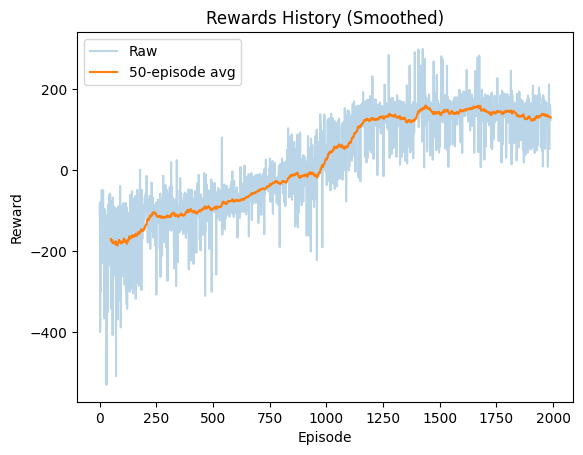

In [5]:
df = pd.read_csv(log_path, skiprows=1)
rewards = df["r"]

plot_reward(rewards)

In [6]:
render_callback(model, env_id)